Verification test for entire pipeline end-to-end and visualize a batch of real EuroSAT images with the new augmentations

[load_eurosat_tfds] Loading dataset 'eurosat/rgb' from TFDS...
[load_eurosat_tfds] Using splits:
  - train: train[:70%]
  - val:   train[70%:85%]
  - test:  train[85%:]


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/eurosat/rgb/incomplete.RFF17R_2.0.0/eurosat-train.tfrecord-[0-9][0-9][0-9]…

Dataset eurosat downloaded and prepared to /root/tensorflow_datasets/eurosat/rgb/2.0.0. Subsequent calls will reuse this data.
[load_eurosat_tfds] Feature dtypes:
  - image dtype: <class 'numpy.uint8'>
  - label dtype: <class 'numpy.int64'>
[load_eurosat_tfds] Dataset info:
  - num_classes: 10
  - image_shape: (64, 64, 3)
  - classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
[build_tfdata_pipelines] Building train pipeline...
[build_tfdata_pipelines] Train batch check:
  image shape: (8, 64, 64, 3), dtype: <dtype: 'uint8'>
  image range: 0 to 209
  label shape: (8,), dtype: <dtype: 'int64'>
Batch Images shape: (8, 64, 64, 3)
Batch Labels shape: (8,)
Value range: 0 to 254


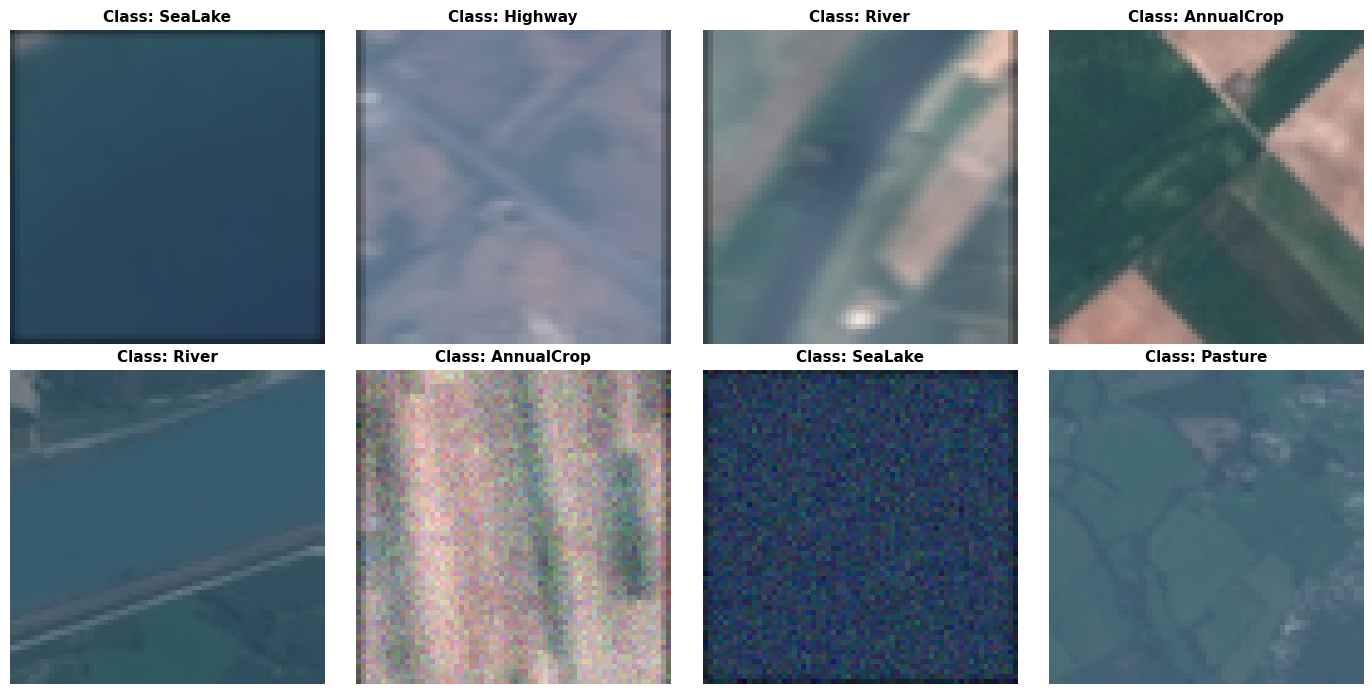

In [3]:
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_datasets.core.load
tfds.builder = tfds.core.load.builder
from core.config import DatasetConfig
from core.dataset import load_eurosat_tfds, build_tfdata_pipelines

cfg = DatasetConfig(
    batch_size=8,
    train_pct=70,
    val_pct=15,
    test_pct=15
)

datasets, info = load_eurosat_tfds(cfg)
pipelines = build_tfdata_pipelines(datasets, cfg)

train_ds = pipelines["train"]
batch_images, batch_labels = next(iter(train_ds.take(1)))

print("Batch Images shape:", batch_images.shape)
print("Batch Labels shape:", batch_labels.shape)
print("Value range:", tf.reduce_min(batch_images).numpy(), "to", tf.reduce_max(batch_images).numpy())

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
class_names = info.features["label"].names
for i in range(8):
    axes[i].imshow(batch_images[i].numpy())
    axes[i].set_title(f"Class: {class_names[batch_labels[i]]}", fontsize=11, fontweight="bold")
    axes[i].axis("off")
    
plt.tight_layout()
plt.show()